# Unemployment Analysis in India

### CodeAlpha Data Science Internship — Task 2

## Project Overview

This project analyzes unemployment trends in India using two unemployment datasets.

The analysis focuses on:

- Unemployment trends over time
- Regional differences in unemployment
- The impact observed during the April–May 2020 COVID-19 period
- Labour participation trends
- Estimated employment trends
- Geographical unemployment patterns
- Correlation between key labour-market indicators

### Objectives

1. Clean and prepare the unemployment datasets.
2. Explore unemployment trends using statistical analysis.
3. Visualize important patterns and regional differences.
4. Examine changes during the 2020 COVID-19 period.
5. Identify meaningful insights from employment and labour participation data.
6. Present policy-relevant observations based on the analyzed data.

### Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load the unemployment dataset

df = pd.read_csv("Unemployment in India.csv")

# Display the first 5 rows
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [3]:
# Load the second unemployment dataset

df2 = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

# Display the first 5 rows
df2.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [4]:
df2 = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

df2.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [5]:
print("Shape:", df2.shape)
print("\nColumns:")
print(df2.columns.tolist())

Shape: (267, 9)

Columns:
['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


In [6]:
print("Missing values:")
print(df2.isnull().sum())

print("\nData types:")
print(df2.dtypes)

Missing values:
Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Region.1                                    0
longitude                                   0
latitude                                    0
dtype: int64

Data types:
Region                                       object
 Date                                        object
 Frequency                                   object
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                           int64
 Estimated Labour Participation Rate (%)    float64
Region.1                                     object
longitude                                   float64
latitude                                    float64
dtype: object


In [7]:
# Remove extra spaces from column names
df2.columns = df2.columns.str.strip()

# Check the cleaned column names
print(df2.columns.tolist())

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


In [8]:
# Convert Date column to datetime
df2["Date"] = pd.to_datetime(df2["Date"], dayfirst=True)

# Check the result
print(df2["Date"].dtype)
print(df2["Date"].head())

datetime64[ns]
0   2020-01-31
1   2020-02-29
2   2020-03-31
3   2020-04-30
4   2020-05-31
Name: Date, dtype: datetime64[ns]


In [9]:
# Check Dataset 1
print("Shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Shape: (768, 7)

Missing values:
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

Data types:
Region                                       object
 Date                                        object
 Frequency                                   object
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                         object
dtype: object


In [10]:
# Remove rows containing missing values
df = df.dropna().copy()

# Check the new shape
print("Shape after removing missing rows:", df.shape)

# Check missing values again
print("\nMissing values:")
print(df.isnull().sum())

Shape after removing missing rows: (740, 7)

Missing values:
Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Area                                        0
dtype: int64


In [11]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Check cleaned column names
print(df.columns.tolist())

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


In [12]:
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

# Check the result
print(df["Date"].dtype)
print(df["Date"].head())

datetime64[ns]
0   2019-05-31
1   2019-06-30
2   2019-07-31
3   2019-08-31
4   2019-09-30
Name: Date, dtype: datetime64[ns]


In [13]:
print("Start Date:", df["Date"].min())
print("End Date:", df["Date"].max())

print("\nNumber of states/regions:", df["Region"].nunique())
print("\nRegions:")
print(df["Region"].unique())

Start Date: 2019-05-31 00:00:00
End Date: 2020-06-30 00:00:00

Number of states/regions: 28

Regions:
['Andhra Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal' 'Chandigarh']


In [14]:
# Calculate average unemployment rate for each month
monthly_unemployment = (
    df.groupby("Date")["Estimated Unemployment Rate (%)"]
      .mean()
      .reset_index()
)

# Display the monthly values
monthly_unemployment

,Date,Estimated Unemployment Rate (%)
0,2019-05-31,8.874259
1,2019-06-30,9.303333
2,2019-07-31,9.033889
3,2019-08-31,9.637925
4,2019-09-30,9.051731
5,2019-10-31,9.900909
6,2019-11-30,9.868364
7,2019-12-31,9.497358
8,2020-01-31,9.950755
9,2020-02-29,9.964717


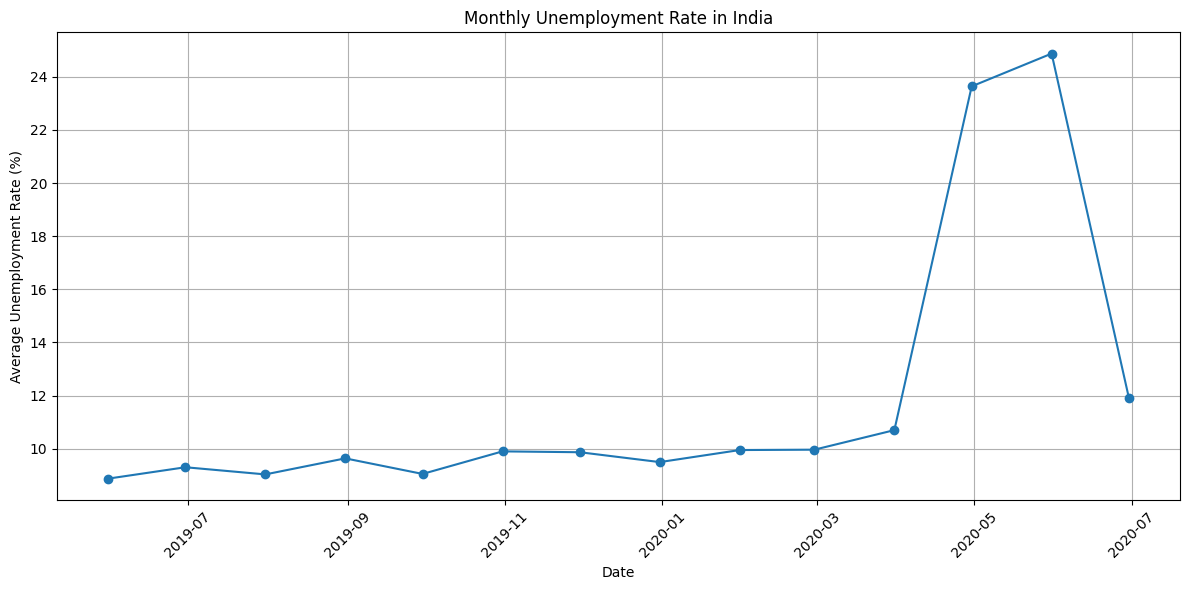

In [15]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_unemployment["Date"],
    monthly_unemployment["Estimated Unemployment Rate (%)"],
    marker="o"
)

plt.title("Monthly Unemployment Rate in India")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

In [16]:
# Calculate average unemployment rate for each region
state_unemployment = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

# Display the results
state_unemployment

,Region,Estimated Unemployment Rate (%)
0,Tripura,28.350357
1,Haryana,26.283214
2,Jharkhand,20.585000
3,Bihar,18.918214
4,Himachal Pradesh,18.540357
5,Delhi,16.495357
6,Jammu & Kashmir,16.188571
7,Chandigarh,15.991667
8,Rajasthan,14.058214
9,Uttar Pradesh,12.551429


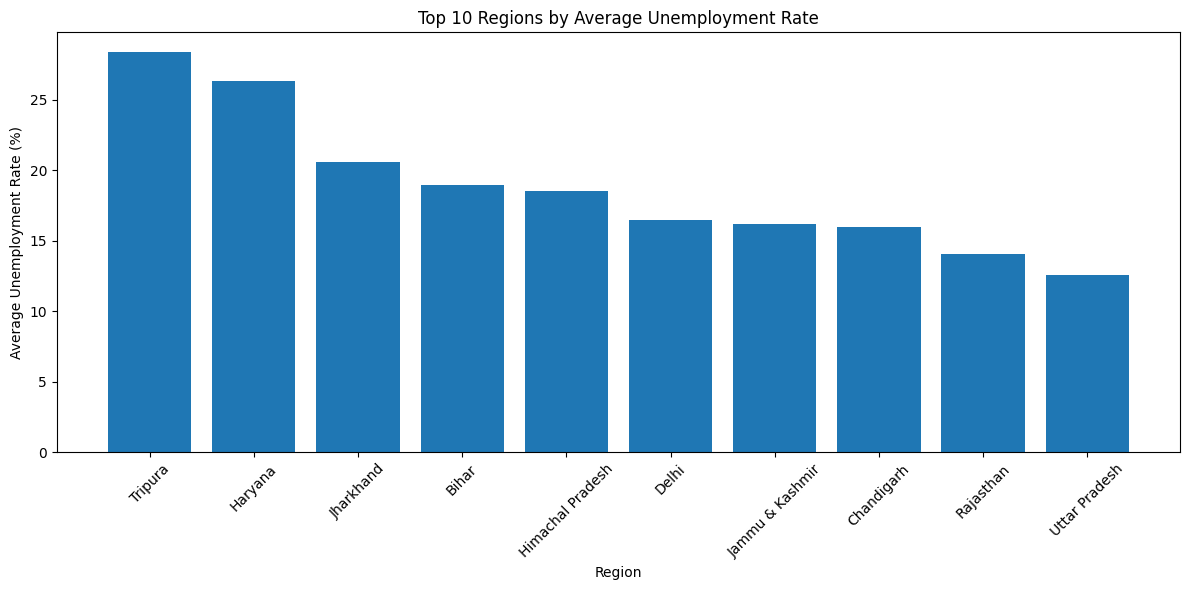

In [17]:
# Select top 10 regions by average unemployment rate
top_10_regions = state_unemployment.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_10_regions["Region"],
    top_10_regions["Estimated Unemployment Rate (%)"]
)

plt.title("Top 10 Regions by Average Unemployment Rate")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [18]:
# Define periods
pre_covid = monthly_unemployment[
    monthly_unemployment["Date"] < "2020-03-01"
]

covid_peak = monthly_unemployment[
    (monthly_unemployment["Date"] >= "2020-04-01") &
    (monthly_unemployment["Date"] <= "2020-05-31")
]

# Calculate averages
pre_covid_avg = pre_covid["Estimated Unemployment Rate (%)"].mean()
covid_peak_avg = covid_peak["Estimated Unemployment Rate (%)"].mean()

# Calculate increase
increase = covid_peak_avg - pre_covid_avg
percentage_increase = (increase / pre_covid_avg) * 100

print(f"Pre-COVID average unemployment rate: {pre_covid_avg:.2f}%")
print(f"April-May 2020 average unemployment rate: {covid_peak_avg:.2f}%")
print(f"Increase: {increase:.2f} percentage points")
print(f"Percentage increase: {percentage_increase:.2f}%")

Pre-COVID average unemployment rate: 9.51%
April-May 2020 average unemployment rate: 24.26%
Increase: 14.75 percentage points
Percentage increase: 155.13%


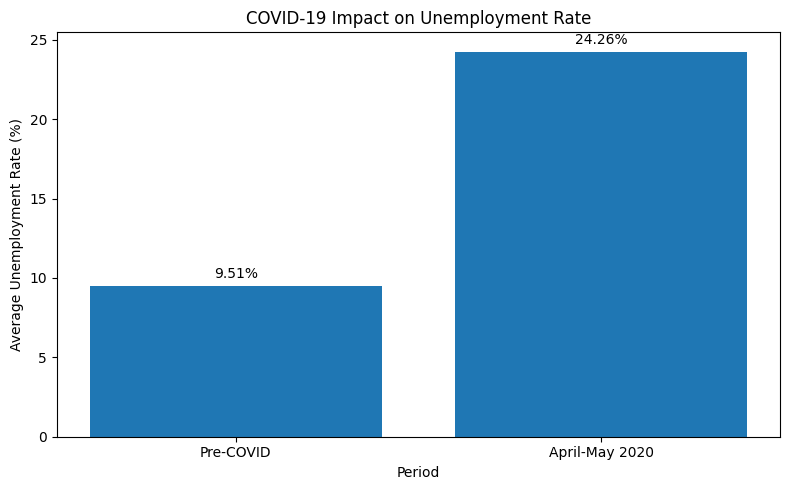

In [19]:
# Prepare data for COVID-19 impact comparison
covid_comparison = pd.DataFrame({
    "Period": ["Pre-COVID", "April-May 2020"],
    "Average Unemployment Rate (%)": [pre_covid_avg, covid_peak_avg]
})

plt.figure(figsize=(8, 5))

plt.bar(
    covid_comparison["Period"],
    covid_comparison["Average Unemployment Rate (%)"]
)

plt.title("COVID-19 Impact on Unemployment Rate")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")

# Add values on top of bars
for i, value in enumerate(covid_comparison["Average Unemployment Rate (%)"]):
    plt.text(i, value + 0.5, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.show()

In [20]:
# Calculate average labour participation rate for each month
monthly_lpr = (
    df.groupby("Date")["Estimated Labour Participation Rate (%)"]
      .mean()
      .reset_index()
)

# Display the monthly values
monthly_lpr

,Date,Estimated Labour Participation Rate (%)
0,2019-05-31,43.902963
1,2019-06-30,43.750556
2,2019-07-31,43.706667
3,2019-08-31,43.646792
4,2019-09-30,44.301346
5,2019-10-31,44.001273
6,2019-11-30,44.110545
7,2019-12-31,43.667358
8,2020-01-31,44.051321
9,2020-02-29,43.723019


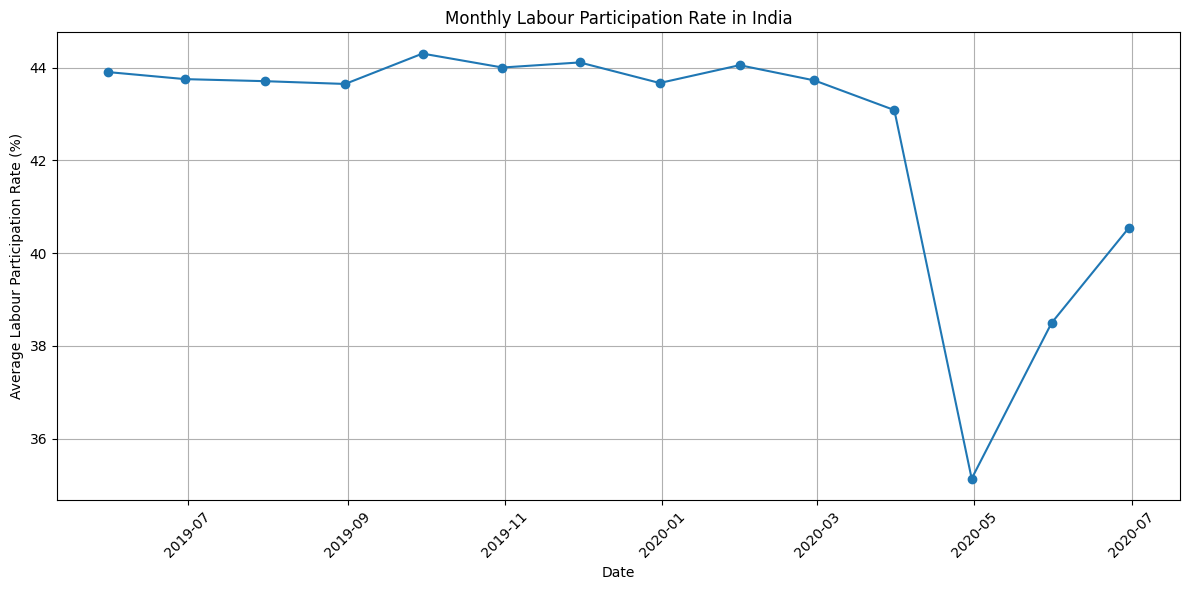

In [21]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_lpr["Date"],
    monthly_lpr["Estimated Labour Participation Rate (%)"],
    marker="o"
)

plt.title("Monthly Labour Participation Rate in India")
plt.xlabel("Date")
plt.ylabel("Average Labour Participation Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

In [22]:
# Calculate total estimated employment for each month
monthly_employment = (
    df.groupby("Date")["Estimated Employed"]
      .sum()
      .reset_index()
)

# Display the monthly employment values
monthly_employment

,Date,Estimated Employed
0,2019-05-31,400148016.0
1,2019-06-30,397366645.0
2,2019-07-31,399838967.0
3,2019-08-31,399610205.0
4,2019-09-30,402452126.0
5,2019-10-31,401411032.0
6,2019-11-30,400051335.0
7,2019-12-31,391001555.0
8,2020-01-31,406899254.0
9,2020-02-29,403011803.0


In [23]:
# Employment change from March to April 2020
march_employment = monthly_employment.loc[
    monthly_employment["Date"] == "2020-03-31",
    "Estimated Employed"
].iloc[0]

april_employment = monthly_employment.loc[
    monthly_employment["Date"] == "2020-04-30",
    "Estimated Employed"
].iloc[0]

employment_drop = march_employment - april_employment
employment_drop_percent = (employment_drop / march_employment) * 100

print(f"March 2020 estimated employment: {march_employment:,.0f}")
print(f"April 2020 estimated employment: {april_employment:,.0f}")
print(f"Estimated decline: {employment_drop:,.0f}")
print(f"Percentage decline: {employment_drop_percent:.2f}%")

March 2020 estimated employment: 390,862,219
April 2020 estimated employment: 269,449,315
Estimated decline: 121,412,904
Percentage decline: 31.06%


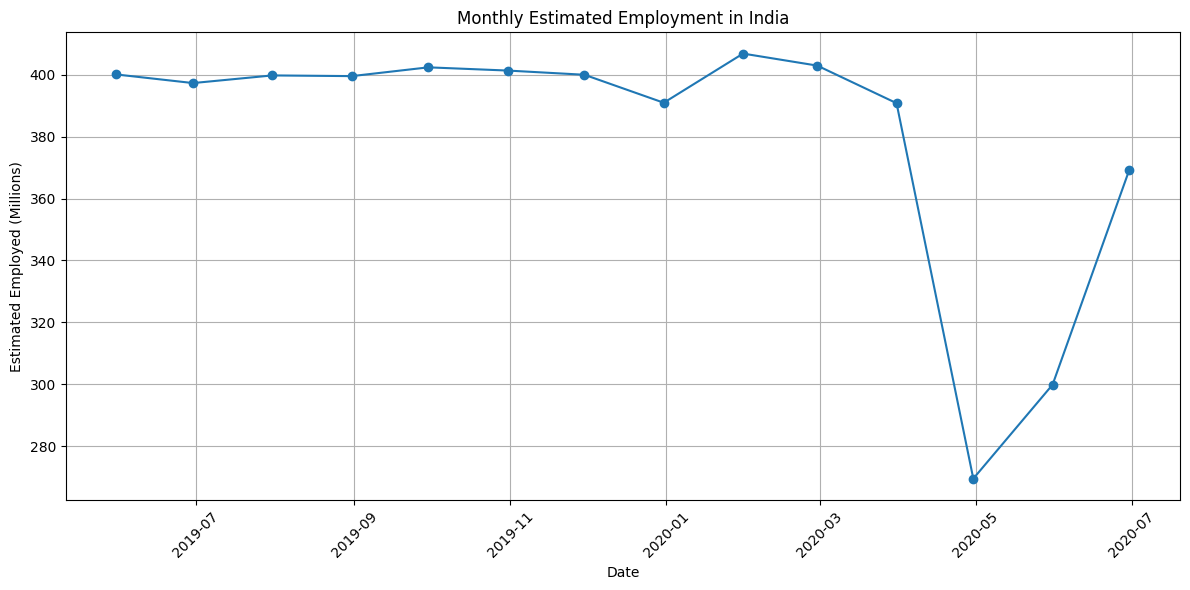

In [24]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_employment["Date"],
    monthly_employment["Estimated Employed"] / 1_000_000,
    marker="o"
)

plt.title("Monthly Estimated Employment in India")
plt.xlabel("Date")
plt.ylabel("Estimated Employed (Millions)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

In [25]:
# Check geographical regions in Dataset 2
print("Geographical regions:")
print(df2["Region.1"].value_counts())

print("\nNumber of states:")
print(df2["Region"].nunique())

Geographical regions:
Region.1
North        79
South        60
West         50
East         40
Northeast    38
Name: count, dtype: int64

Number of states:
27


In [26]:
# Calculate average unemployment rate by geographical region
regional_unemployment = (
    df2.groupby("Region.1")["Estimated Unemployment Rate (%)"]
       .mean()
       .sort_values(ascending=False)
       .reset_index()
)

regional_unemployment

,Region.1,Estimated Unemployment Rate (%)
0,North,15.889620
1,East,13.916000
2,Northeast,10.950263
3,South,10.454667
4,West,8.239000


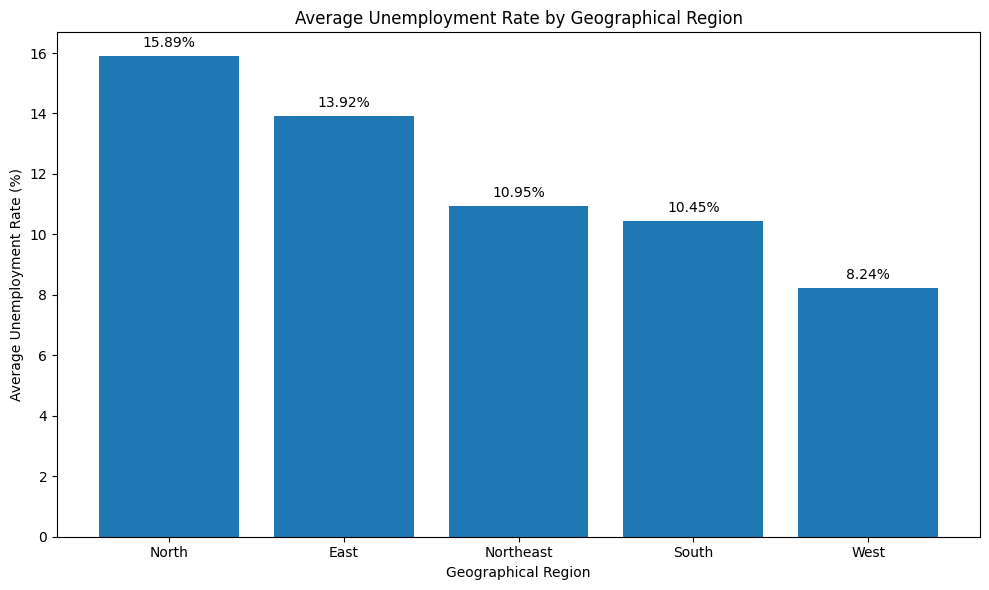

In [27]:
plt.figure(figsize=(10, 6))

plt.bar(
    regional_unemployment["Region.1"],
    regional_unemployment["Estimated Unemployment Rate (%)"]
)

plt.title("Average Unemployment Rate by Geographical Region")
plt.xlabel("Geographical Region")
plt.ylabel("Average Unemployment Rate (%)")

# Add values on top of bars
for i, value in enumerate(
    regional_unemployment["Estimated Unemployment Rate (%)"]
):
    plt.text(i, value + 0.3, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.show()

In [28]:
# Calculate correlations between key employment indicators
correlation_data = df[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
]

correlation_matrix = correlation_data.corr()

correlation_matrix

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


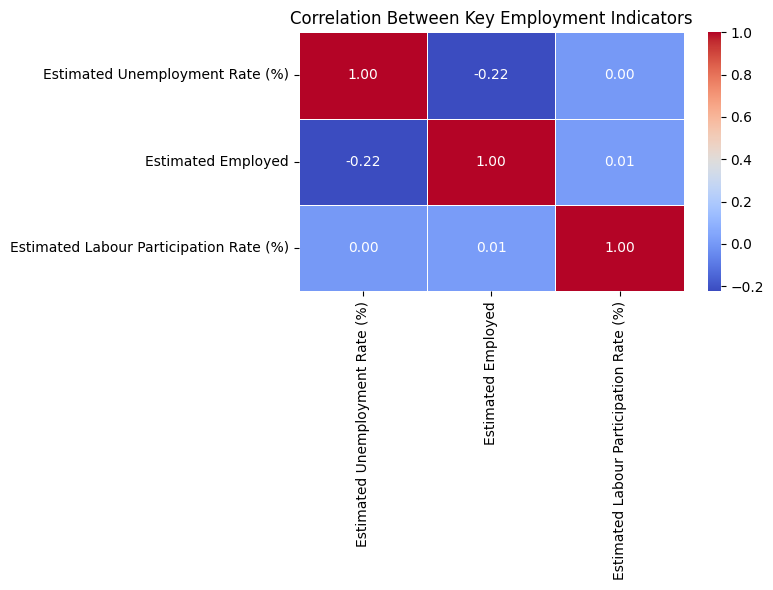

In [29]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Between Key Employment Indicators")
plt.tight_layout()

plt.show()

In [30]:
# Key COVID-period summary

march = df[df["Date"] == "2020-03-31"].iloc[0]
april = df[df["Date"] == "2020-04-30"].iloc[0]

print("COVID-19 Period Summary")
print("-" * 35)

print(f"Average unemployment rate (pre-COVID): {pre_covid_avg:.2f}%")
print(f"Average unemployment rate (April-May 2020): {covid_peak_avg:.2f}%")
print(f"Unemployment increase: {increase:.2f} percentage points")
print(f"Relative unemployment increase: {percentage_increase:.2f}%")

print(f"\nMarch 2020 estimated employment: {march_employment:,.0f}")
print(f"April 2020 estimated employment: {april_employment:,.0f}")
print(f"Employment decline: {employment_drop:,.0f}")
print(f"Employment decline percentage: {employment_drop_percent:.2f}%")

print(f"\nMarch 2020 labour participation: {monthly_lpr.loc[monthly_lpr['Date'] == '2020-03-31', 'Estimated Labour Participation Rate (%)'].iloc[0]:.2f}%")
print(f"April 2020 labour participation: {monthly_lpr.loc[monthly_lpr['Date'] == '2020-04-30', 'Estimated Labour Participation Rate (%)'].iloc[0]:.2f}%")

COVID-19 Period Summary
-----------------------------------
Average unemployment rate (pre-COVID): 9.51%
Average unemployment rate (April-May 2020): 24.26%
Unemployment increase: 14.75 percentage points
Relative unemployment increase: 155.13%

March 2020 estimated employment: 390,862,219
April 2020 estimated employment: 269,449,315
Employment decline: 121,412,904
Employment decline percentage: 31.06%

March 2020 labour participation: 43.08%
April 2020 labour participation: 35.14%


## Key Insights

### 1. Overall Unemployment Trend
The average unemployment rate remained relatively stable at around 9–10% from May 2019 to March 2020. A sharp increase was observed during April and May 2020, when the average rate reached 23.64% and 24.88%, respectively.

### 2. COVID-19 Period Impact
The average unemployment rate increased from 9.51% during the pre-COVID period (May 2019–February 2020) to 24.26% during April–May 2020. This represents an increase of 14.75 percentage points, or approximately 155.13% relative to the pre-COVID average.

### 3. Employment Decline
Estimated employment decreased from approximately 390.86 million in March 2020 to 269.45 million in April 2020, representing a decline of approximately 121.41 million or 31.06%.

### 4. Labour Participation
The average labour participation rate declined from 43.08% in March 2020 to 35.14% in April 2020. It subsequently showed a partial recovery during May and June 2020.

### 5. Regional Variation
Average unemployment rates varied considerably across regions. In Dataset 1, Tripura and Haryana recorded the highest period-average unemployment rates among the regions included in the analysis.

### 6. Geographical Variation
Dataset 2 showed differences in average unemployment rates across geographical regions, with the North and East showing higher period averages than the South and West in this dataset.

### 7. Correlation Analysis
The correlation analysis showed a weak negative relationship between estimated employment and unemployment rate (-0.22). The relationships between unemployment and labour participation, and between employment and labour participation, were close to zero in the full dataset.

## Policy-Relevant Observations

The analysis provides several observations that can be useful when considering employment and labour-market policy:

- The sharp increase in unemployment during April–May 2020 highlights the importance of emergency employment-support measures during major economic disruptions.
- The decline in estimated employment and labour participation during April 2020 suggests that labour-market disruptions affected both employment levels and participation.
- The substantial variation in unemployment rates across regions indicates that employment conditions can differ considerably geographically. Regional labour-market policies can therefore benefit from considering local conditions.
- The geographical analysis in Dataset 2 shows differences in average unemployment rates across North, East, Northeast, South, and West regions.
- Regular monitoring of unemployment, employment, and labour participation indicators can help identify significant changes in labour-market conditions and support timely policy responses.

## Conclusion

This project analyzed unemployment trends in India using two unemployment datasets. The analysis included data cleaning, exploratory analysis, visualization, regional comparison, COVID-19-period analysis, labour participation analysis, employment analysis, geographical comparison, and correlation analysis.

The results show that unemployment remained relatively stable during much of the period from May 2019 to March 2020, followed by a sharp increase during April and May 2020. The average unemployment rate increased from 9.51% during the pre-COVID period to 24.26% during April–May 2020.

At the same time, estimated employment declined by approximately 31.06% between March and April 2020, while the average labour participation rate decreased from 43.08% to 35.14%.

The analysis also revealed substantial regional and geographical variation in unemployment rates. Overall, the project demonstrates how Python, Pandas, Matplotlib, Seaborn, and statistical analysis can be used to explore labour-market data and identify important trends and patterns.